# Airbnb Listings Analysis

This project analyzes Airbnb listings in Paris to explore pricing, neighbourhood differences, accommodation capacity, and changes in listings over time.

## Objectives

1. **Profile and QA the data** — inspect, clean, and prepare the Airbnb listings data for analysis.
2. **Prepare the data for visualization** — create aggregated tables to analyze prices, neighbourhoods, accommodation capacity, and new hosts over time.
3. **Visualize and summarize findings** — create charts to identify patterns in prices and new hosts and investigate the potential impact of the 2015 regulations.

## Objective 1 — Profile & QA the Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
listings = pd.read_csv("Listings.csv",  low_memory=False, encoding="ISO-8859-1")


In [5]:
listings["host_since"] = pd.to_datetime(listings['host_since'])

In [8]:
paris_listings = listings.loc[
    listings["city"] == "Paris",
    ["host_since", "neighbourhood", "city", "accommodates", "price"]
    ].copy()

In [9]:
paris_listings.isna().sum()

host_since       33
neighbourhood     0
city              0
accommodates      0
price             0
dtype: int64

In [15]:
paris_listings[["accommodates", "price"]].describe().loc[["min", "max", "mean"]]
# or simply write paris_listings.describe()
# that gives "count, mean, standard deviation, min, max, 25%, 50%, 75%"

,accommodates,price
min,0.000000,0.000000
max,16.000000,12000.000000
mean,3.037997,113.096445


## Objective 2 — Prepare the Data for Visualization

#### Average price by neighbourhood

In [18]:
paris_listings_neighbourhood = (
    paris_listings.groupby("neighbourhood")["price"].mean()
    .sort_values(ascending=True))
paris_listings_neighbourhood

neighbourhood
Menilmontant            74.942257
Buttes-Chaumont         82.690182
Buttes-Montmartre       87.209479
Reuilly                 89.058402
Popincourt              90.559459
Gobelins                98.110184
Observatoire           101.866801
Batignolles-Monceau    102.612702
Enclos-St-Laurent      102.967156
Vaugirard              106.831330
Opera                  119.038644
Pantheon               122.662150
Temple                 138.446823
Hotel-de-Ville         144.472110
Bourse                 149.496801
Luxembourg             155.638639
Palais-Bourbon         156.856578
Passy                  161.144635
Louvre                 175.379972
Elysee                 210.536765
Name: price, dtype: float64

#### Most expensive neighbourhood

In [22]:
most_expensive_neighbourhood = paris_listings_neighbourhood.idxmax()
# .idxmax() returns the label of the highest value
paris_listings_accomodations = (
    paris_listings[paris_listings["neighbourhood"] == most_expensive_neighbourhood]
    .groupby("accommodates")["price"]
    .mean()
    .sort_values(ascending=True)
)
most_expensive_neighbourhood

'Elysee'

#### Listings over time

In [25]:
paris_listings_overtime = (
    paris_listings.groupby(paris_listings["host_since"].dt.year)
    .agg(avg_price=("price", "mean"), new_hosts=("price", "count"))
)
paris_listings_overtime

,avg_price,new_hosts
host_since,,
2008.0,77.750000,4
2009.0,159.641509,106
2010.0,125.031250,416
2011.0,124.828230,1339
2012.0,111.578615,4592
2013.0,107.096414,8142
2014.0,100.253800,10922
2015.0,103.646250,12147
2016.0,114.159847,8871


## Objective 3 — Visualize the Data and Summarize Findings

#### Chart 1 - Average price by neighbourhood in Paris

Text(0, 0.5, 'Neighbourhood')

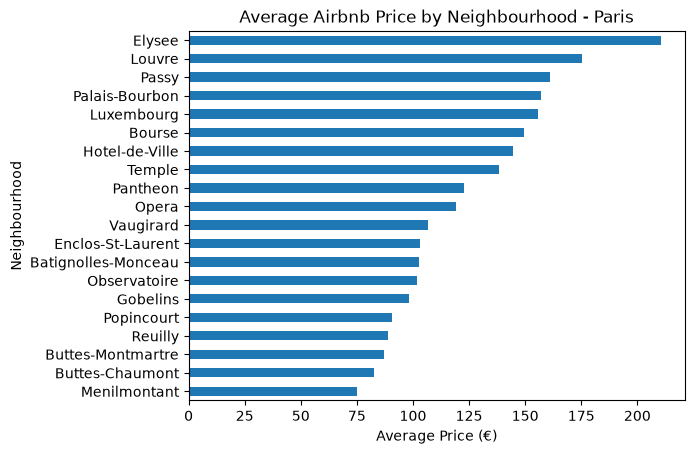

In [30]:
paris_listings_neighbourhood.plot(kind='barh')
# kind='barh' = horizontal bar chart, directly from the pandas Series (it plots the index as categories, values as bar length).
plt.title('Average Airbnb Price by Neighbourhood - Paris')
plt.xlabel('Average Price (€)')
plt.ylabel('Neighbourhood')

#### Chart 2 - Price by accommodation capacity

Text(0, 0.5, 'Number of Guests Accommodated')

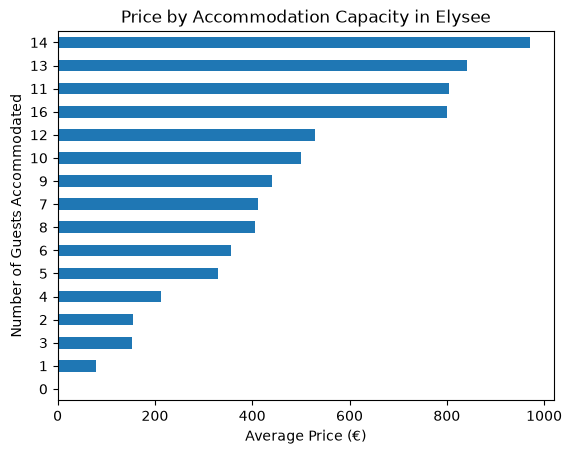

In [36]:
paris_listings_accomodations.plot(kind='barh')
plt.title(
    f"Price by Accommodation Capacity in {most_expensive_neighbourhood}"
)

plt.xlabel("Average Price (€)")
plt.ylabel("Number of Guests Accommodated")


#### Chart 3 - New hosts over time

(0.0, 12754.15)

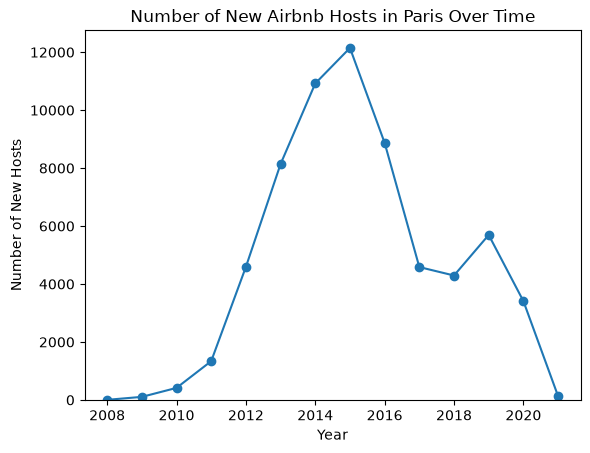

In [40]:
paris_listings_overtime['new_hosts'].plot(kind='line', marker='o')
plt.title("Number of New Airbnb Hosts in Paris Over Time")
plt.xlabel("Year")
plt.ylabel("Number of New Hosts")
plt.ylim(bottom=0)
# marker='o' adds a dot at each year's point (easier to read than a bare line).
# plt.ylim(bottom=0) forces the y-axis to start at 0, as the brief asked — otherwise matplotlib zooms in and can exaggerate small changes.

#### Chart 4 - Average price over time

(0.0, 163.73608490566036)

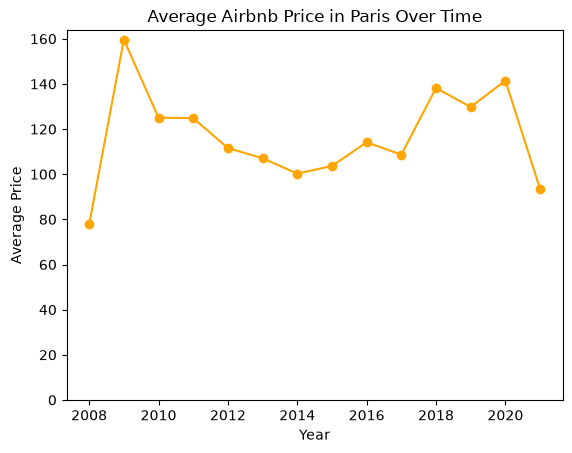

In [59]:
paris_listings_overtime['avg_price'].plot(kind='line', marker='o', color='orange')

plt.title("Average Airbnb Price in Paris Over Time")
plt.xlabel("Year")
plt.ylabel("Average Price")

plt.ylim(bottom=0)

#### Chart 5 - Dual axis of "New hosts" & "Average price" overtime

Text(0.5, 1.0, 'New Hosts and Average Airbnb Price Over Time')

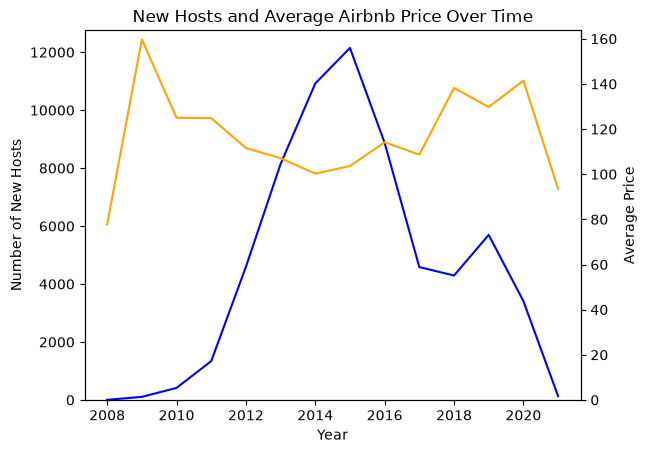

In [58]:
fig, ax1 = plt.subplots()
ax1.plot(paris_listings_overtime['new_hosts'], color='blue')
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of New Hosts")
ax1.set_ylim(bottom=0)
ax2 = ax1.twinx()
ax2.plot(paris_listings_overtime['avg_price'], color='orange')
ax2.set_ylabel("Average Price")
ax2.set_ylim(bottom=0)

plt.title("New Hosts and Average Airbnb Price Over Time")


## Key Findings

Based on the analysis and visualizations:

* The average Airbnb price varies considerably across Paris neighbourhoods.
* The most expensive neighbourhood identified in the analysis was **Elysée**.
* Within this neighbourhood, average prices generally increase as accommodation capacity increases — from around €80 for a single guest up to €800+ for listings that sleep 11 or more.
* The number of new hosts increased sharply up to a peak in 2015 (12,147 new hosts), then declined noticeably in the following years.
* Average Airbnb prices stayed relatively flat and low around 2014–2015, then gradually rose in the years after.

### Impact of the 2015 Regulations

The charts show a sharp drop in the growth of new hosts following the introduction of the 2015 regulations, after new-host counts had been climbing every year before that point. Average prices did not fall alongside this drop — they held steady through 2015 and then trended upward in the following years.

These observations show a relationship between the timing of the regulations and changes in Airbnb listings and prices, but the analysis alone does not establish that the regulations caused these changes.
